# Signal Engine — Intraday Forecasting with Risk Management

**How to use:**
1. Edit **Cell 2 (CONFIG)** only — set your asset, timeframe, and account size.
2. Run all cells top-to-bottom (`Kernel → Restart & Run All`).
3. The signal cell prints entry / TP / SL and position size.
4. Optionally enable the live scanner (last cell) for continuous updates.

**Prediction engine:** AutoTheta + AutoETS ensemble (statsforecast).  
**Risk management:** ATR-based SL, fixed-fractional position sizing, R:R filter.  
**Extra filters:** ADX trend strength, RSI regime, multi-TF bias alignment.

In [787]:
import sys, os, warnings, threading, time
warnings.filterwarnings('ignore')
ROOT = os.path.abspath('..')
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, timezone

from statsforecast import StatsForecast
from statsforecast.models import AutoTheta, AutoETS

# ── Use MT5 for real-time data (no yfinance delay) ────────────────────────
from src.mt5_feed import fetch_multi_timeframe, initialize as mt5_init
mt5_init()

from src.feature_engineering import compute_features, build_multi_tf_snapshot, atr as calc_atr, rsi as calc_rsi
from src.signal_engine       import _score_timeframe
from src.signal_logger       import SignalLogger

plt.rcParams.update({
    'figure.dpi': 120, 'axes.grid': True, 'grid.alpha': 0.25,
    'axes.spines.top': False, 'axes.spines.right': False
})

print('Imports OK')
print('Data source: MT5 (real-time)')
print('Supported assets: XAUUSD, XAGUSD, EURUSD, GBPUSD, USDJPY, USDCHF, AUDUSD, USDCAD, NZDUSD, GBPJPY, EURJPY, EURGBP')

Imports OK
Data source: MT5 (real-time)
Supported assets: XAUUSD, XAGUSD, EURUSD, GBPUSD, USDJPY, USDCHF, AUDUSD, USDCAD, NZDUSD, GBPJPY, EURJPY, EURGBP


In [788]:
# ── Load Chronos zero-shot model (cached after first load) ───────────────
# Benchmark Sharpe (H=1): AutoTheta=0.771, Chronos=0.498, AutoETS=0.162
# Weights are normalised so they sum to 1.0.
_SHARPE = {'AutoTheta': 0.771, 'AutoETS': 0.162, 'Chronos': 0.498}
_W_SUM  = sum(_SHARPE.values())
MODEL_WEIGHTS = {k: v / _W_SUM for k, v in _SHARPE.items()}

_chronos_forecaster = None   # lazy-loaded below

def _load_chronos():
    global _chronos_forecaster
    if _chronos_forecaster is not None:
        return _chronos_forecaster
    try:
        from src.new_models import ChronosZeroShotForecaster
        print('Loading Chronos-bolt-tiny ...', end=' ', flush=True)
        _chronos_forecaster = ChronosZeroShotForecaster('amazon/chronos-bolt-tiny')
        print('OK')
    except Exception as e:
        print(f'Chronos load failed ({e}) — will use AutoTheta+AutoETS only')
        _chronos_forecaster = None
    return _chronos_forecaster

print(f'Model weights  : AutoTheta={MODEL_WEIGHTS["AutoTheta"]:.3f}  '
      f'AutoETS={MODEL_WEIGHTS["AutoETS"]:.3f}  Chronos={MODEL_WEIGHTS["Chronos"]:.3f}')
print('Chronos        : will load on first forecast call')

Model weights  : AutoTheta=0.539  AutoETS=0.113  Chronos=0.348
Chronos        : will load on first forecast call


In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║              EDIT ONLY THIS CELL                           ║
# ╚══════════════════════════════════════════════════════════════╝

# ── Asset & Timeframe ──────────────────────────────────────────
ASSET    = 'XAUUSD'   # XAUUSD | EURUSD | GBPUSD | USDJPY | USDCAD | GBPJPY
ENTRY_TF = '15min'    # 1min | 5min | 15min | 30min | 1H | 4H | 1D

# ── Prediction ─────────────────────────────────────────────────
TRAIN_BARS  = 400     # bars of history fed to each model
FORECAST_H  = 4       # how many bars ahead to predict

# ── Model ensemble (toggle Chronos — adds ~3s on first call) ───
USE_CHRONOS = True

# ── Risk Management ────────────────────────────────────────────
ACCOUNT_BALANCE = 100.0
MAX_RISK_PCT    = 0.01
RR_RATIO        = 2.0
ATR_SL_MULT     = 1.5  # Sweeps local noise but keeps SL tight (~50-100 pips)
MIN_RR          = 1.5


# ── Filters ────────────────────────────────────────────────────
CONFIDENCE_THRESHOLD = 55
ADX_TREND_THRESHOLD  = 30 # ADX above 22 which we consider the market to be trending (no mean reversion signals)
RSI_OVERBOUGHT       = 75 # RSI above this level is considered overbought (potential sell signal)
RSI_OVERSOLD         = 25 # RSI below this level is considered oversold (potential buy signal)
USE_SMC_FILTER       = True  # Toggle SMC validation on/off (structure break + OB + FVG)

# ── TF stack for multi-timeframe bias ──────────────────────────
_TF_STACKS = {
    '1min':  ['1min',  '5min',  '15min', '30min', '1H', '4H', '1D'],
    '5min':  ['5min',  '15min', '1H',    '4H', '1D'],
    '15min': ['15min', '1H',    '4H', '1D'],
    '30min': ['30min', '1H',    '4H', '1D'],
    '1H':    ['1H',    '4H',    '1D'],
    '4H':    ['4H',    '1D'],
    '1D':    ['1D'],
}
TIMEFRAMES = _TF_STACKS.get(ENTRY_TF, [ENTRY_TF])

print(f'Asset      : {ASSET}')
print(f'Entry TF   : {ENTRY_TF}  |  TF stack: {TIMEFRAMES}')
print(f'Train bars : {TRAIN_BARS}  |  Forecast: {FORECAST_H} bars ahead')
print(f'Chronos    : {"ON" if USE_CHRONOS else "OFF"}')
print(f'SMC Filter : {"ON" if USE_SMC_FILTER else "OFF"}')
print(f'Account    : ${ACCOUNT_BALANCE:,.0f}  |  Risk/trade: {MAX_RISK_PCT:.1%}')
print(f'R:R target : 1:{RR_RATIO}  |  ATR SL mult: {ATR_SL_MULT}x  |  Min R:R: {MIN_RR}')
print(f'Filters    : Conf>={CONFIDENCE_THRESHOLD}%  ADX>={ADX_TREND_THRESHOLD}  RSI OB={RSI_OVERBOUGHT} OS={RSI_OVERSOLD}')

In [790]:
import requests
from datetime import datetime, timezone

def get_news_events():
    try:
        url = (
            "https://nfs.faireconomy.media/"
            "ff_calendar_thisweek.json"
        )
        response = requests.get(url, timeout=10)
        events = response.json()
        now = datetime.now(timezone.utc)
        upcoming = []
        for event in events:
            if event.get('impact') != 'High':
                continue
            try:
                event_time = datetime.fromisoformat(
                    event['date'].replace('Z', '+00:00')
                )
                diff_minutes = (
                    event_time - now
                ).total_seconds() / 60
                if -30 <= diff_minutes <= 60:
                    upcoming.append({
                        'title':   event.get('title', ''),
                        'country': event.get('country', ''),
                        'minutes': diff_minutes
                    })
            except:
                continue
        return upcoming
    except:
        return []

def is_news_zone():
    events = get_news_events()
    gold_relevant = ['USD', 'XAU', 'US']
    for event in events:
        if event['country'] in gold_relevant:
            return True, event
    return False, None

def get_fear_greed():
    try:
        url = (
            "https://production.dataviz.cnn.io/"
            "index/fearandgreed/graphdata"
        )
        headers = {'User-Agent': 'Mozilla/5.0'}
        r = requests.get(
            url, headers=headers, timeout=10
        )
        data = r.json()
        score  = float(
            data['fear_and_greed']['score']
        )
        rating = data['fear_and_greed']['rating']
        return score, rating
    except:
        return 50, 'neutral'

def get_sentiment_bias(direction):
    score, rating = get_fear_greed()
    if direction == 'BUY':
        if score < 40:
            return f'😨 Fear ({score:.0f}) confirms BUY'
        elif score > 60:
            return f'😎 Greed ({score:.0f}) caution BUY'
        else:
            return f'😐 Neutral ({score:.0f})'
    else:
        if score > 60:
            return f'😎 Greed ({score:.0f}) confirms SELL'
        elif score < 40:
            return f'😨 Fear ({score:.0f}) caution SELL'
        else:
            return f'😐 Neutral ({score:.0f})'

print("Functions defined ✓")

Functions defined ✓


In [791]:
print(f'Fetching {ASSET} data ...')
tf_data = fetch_multi_timeframe(ASSET, TIMEFRAMES, bars=500)

for tf, df in tf_data.items():
    atr14 = calc_atr(df, 14).iloc[-1]
    print(f'  {tf:6s}: {len(df):4d} bars | last={df["close"].iloc[-1]:.3f} | ATR(14)={atr14:.3f} | {df.index[-1]}')

entry_df  = tf_data[ENTRY_TF]
cur_price = float(entry_df['close'].iloc[-1])
cur_atr   = float(calc_atr(entry_df, 14).iloc[-1])
cur_time  = entry_df.index[-1]

print(f'\nCurrent price : {cur_price:.5f}')
print(f'Current ATR14 : {cur_atr:.5f}')
print(f'Last bar time : {cur_time}')

Fetching XAUUSD data ...
  15min :  500 bars | last=4297.690 | ATR(14)=9.869 | 2026-06-18 12:30:00+02:00
  1H    :  500 bars | last=4297.690 | ATR(14)=23.189 | 2026-06-18 12:00:00+02:00
  4H    :  500 bars | last=4297.690 | ATR(14)=44.533 | 2026-06-18 10:00:00+02:00
  1D    :  500 bars | last=4297.700 | ATR(14)=115.503 | 2026-06-18 02:00:00+02:00

Current price : 4297.69000
Current ATR14 : 9.86870
Last bar time : 2026-06-18 12:30:00+02:00


In [792]:
# ── 3-model ensemble: AutoTheta + AutoETS + Chronos ──────────────────────
# Weights derived from walk-forward Sharpe in the benchmark (H=1).

def _season_len(tf):
    return {'1min': 390, '5min': 78, '15min': 26, '30min': 13,
            '1H': 7, '4H': 2, '1D': 5}.get(tf, 10)


def _run_statsforecast(df, tf, train_bars, h):
    """Returns (theta_ret[h], ets_ret[h]) as 1-D arrays of log-return forecasts."""
    close   = df['close'].dropna()
    log_ret = np.log(close / close.shift(1)).dropna()
    series  = log_ret.iloc[-train_bars:].values.astype(float)
    n, sl   = len(series), _season_len(tf)
    sf_df = pd.DataFrame({
        'unique_id': ['asset'] * n,
        'ds': pd.date_range('2000-01-01', periods=n, freq='15min'),
        'y': series,
    })
    preds = StatsForecast(
        models=[AutoTheta(season_length=sl), AutoETS(season_length=sl)],
        freq='15min', n_jobs=1
    ).forecast(df=sf_df, h=h)
    return preds['AutoTheta'].values, preds['AutoETS'].values


def _run_chronos(df, train_bars, h):
    """Returns predicted return for bar +h (raw price context, zero-shot)."""
    forecaster = _load_chronos()
    if forecaster is None:
        return None
    close   = df['close'].dropna()
    context = close.iloc[-train_bars:].values.astype(float)
    pred_path = forecaster.predict_close_path(context, prediction_length=h)
    last_px   = float(close.iloc[-1])
    # Convert predicted price at horizon h to cumulative log-return
    pred_log_ret = np.log(pred_path / last_px)     # shape (h,)
    return pred_log_ret                             # array of log-rets per bar


def run_ensemble_forecast(df, tf, train_bars, h, use_chronos=True):
    close    = df['close'].dropna()
    last_px  = float(close.iloc[-1])

    theta, ets = _run_statsforecast(df, tf, train_bars, h)

    # Chronos works on cumulative log-returns; convert theta/ets to same space
    theta_cum = np.cumsum(theta)
    ets_cum   = np.cumsum(ets)

    w_theta = MODEL_WEIGHTS['AutoTheta']
    w_ets   = MODEL_WEIGHTS['AutoETS']
    w_chron = MODEL_WEIGHTS['Chronos']

    chronos_cum = None
    if use_chronos:
        chronos_log = _run_chronos(df, train_bars, h)
        if chronos_log is not None:
            chronos_cum = chronos_log   # already cumulative from predict_close_path

    if chronos_cum is not None:
        # Re-normalise weights to only active models
        w_sum   = w_theta + w_ets + w_chron
        ens_cum = (w_theta * theta_cum + w_ets * ets_cum + w_chron * chronos_cum) / w_sum
    else:
        w_sum   = w_theta + w_ets
        ens_cum = (w_theta * theta_cum + w_ets * ets_cum) / w_sum

    pred_prices = [last_px * np.exp(ens_cum[i]) for i in range(h)]

    # Bar-1 return drives the direction signal
    pred_ret = float(ens_cum[0])

    return {
        'theta':        theta,
        'ets':          ets,
        'chronos_cum':  chronos_cum,
        'ensemble_cum': ens_cum,
        'pred_prices':  pred_prices,
        'direction':    int(np.sign(pred_ret)),
        'pred_return':  pred_ret,
        'chronos_used': chronos_cum is not None,
    }


# ── Run ───────────────────────────────────────────────────────────────────
print('Running ensemble forecast ...')
fc = run_ensemble_forecast(entry_df, ENTRY_TF, TRAIN_BARS, FORECAST_H, use_chronos=USE_CHRONOS)

dir_label = 'BUY' if fc['direction'] > 0 else ('SELL' if fc['direction'] < 0 else 'NEUTRAL')
models_used = ['AutoTheta', 'AutoETS'] + (['Chronos'] if fc['chronos_used'] else [])
print(f'Models used : {", ".join(models_used)}')
print(f'\nEnsemble forecast ({ENTRY_TF}, {FORECAST_H} bars ahead):')
print(f'  Direction   : {dir_label}')
print(f'  Pred return : {fc["pred_return"]:+.5f}  ({fc["pred_return"]*100:+.3f}%)')
print(f'  Pred prices : {", ".join([f"{p:.3f}" for p in fc["pred_prices"]])}')
print()
hdr = f'  {"Bar":5s}  {"AutoTheta":>12s}  {"AutoETS":>12s}'
if fc['chronos_used']:
    hdr += f'  {"Chronos":>12s}'
hdr += f'  {"Ensemble":>12s}'
print(hdr)
for i in range(FORECAST_H):
    row = f'  Bar+{i+1}  {fc["theta"][i]:>+12.5f}  {fc["ets"][i]:>+12.5f}'
    if fc['chronos_used']:
        # Show per-bar log-ret (diff of cumsum for i>0)
        c_bar = fc['chronos_cum'][i] - (fc['chronos_cum'][i-1] if i > 0 else 0)
        row += f'  {c_bar:>+12.5f}'
    row += f'  {fc["ensemble_cum"][i]:>+12.5f}'
    print(row)

Running ensemble forecast ...
Loading Chronos-bolt-tiny ... OK
Models used : AutoTheta, AutoETS, Chronos

Ensemble forecast (15min, 4 bars ahead):
  Direction   : BUY
  Pred return : +0.00009  (+0.009%)
  Pred prices : 4298.057, 4297.875, 4297.571, 4297.002

  Bar       AutoTheta       AutoETS       Chronos      Ensemble
  Bar+1      -0.00026      -0.00002      +0.00066      +0.00009
  Bar+2      -0.00026      -0.00002      +0.00029      +0.00004
  Bar+3      -0.00026      -0.00002      +0.00021      -0.00003
  Bar+4      -0.00026      -0.00002      +0.00004      -0.00016


In [793]:
# ── Market context: multi-TF bias + all indicators ────────────────────────

snapshots = build_multi_tf_snapshot(tf_data)
scores    = {tf: _score_timeframe(snap) for tf, snap in snapshots.items()}
buy_tfs   = [tf for tf, sc in scores.items() if sc['direction'] ==  1]
sell_tfs  = [tf for tf, sc in scores.items() if sc['direction'] == -1]

print('Multi-timeframe bias:')
print(f'  {"TF":6s}  {"Direction":10s}  {"Strength":8s}  Factors')
print('  ' + '-'*70)
for tf, sc in scores.items():
    d = {1: 'BULLISH', -1: 'BEARISH', 0: 'NEUTRAL'}[sc['direction']]
    print(f'  {tf:6s}  {d:10s}  {sc["strength"]:.3f}     {", ".join(sc["factors"][:5])}')

# ── All indicators via compute_features (single source of truth) ──────────
feat     = compute_features(entry_df)
rsi_v    = float(feat['rsi_14'].iloc[-1])   if 'rsi_14'    in feat.columns else 50.0
adx_v    = float(feat['adx_14'].iloc[-1])   if 'adx_14'    in feat.columns else 0.0
plus_di  = float(feat['plus_di'].iloc[-1])  if 'plus_di'   in feat.columns else 0.0
minus_di = float(feat['minus_di'].iloc[-1]) if 'minus_di'  in feat.columns else 0.0
ema20    = float(feat['ema_20'].iloc[-1])   if 'ema_20'    in feat.columns else cur_price
ema50    = float(feat['ema_50'].iloc[-1])   if 'ema_50'    in feat.columns else cur_price
macd_h   = float(feat['macd_hist'].iloc[-1])if 'macd_hist' in feat.columns else 0.0
stoch_k  = float(feat['stoch_k'].iloc[-1])  if 'stoch_k'   in feat.columns else 50.0
bb_pct   = float(feat['bb_pct'].iloc[-1])   if 'bb_pct'    in feat.columns else 0.5

# Volatility regime: current ATR vs 20-bar ATR average
atr_ma     = calc_atr(entry_df, 14).rolling(20).mean().iloc[-1]
vol_regime = 'HIGH' if cur_atr > atr_ma * 1.2 else ('LOW' if cur_atr < atr_ma * 0.8 else 'NORMAL')

print(f'\nEntry-TF indicators ({ENTRY_TF}):')
print(f'  RSI(14)    : {rsi_v:.1f}  {"[OVERBOUGHT]" if rsi_v > RSI_OVERBOUGHT else "[OVERSOLD]" if rsi_v < RSI_OVERSOLD else ""}')
print(f'  Stoch %K   : {stoch_k:.1f}')
print(f'  ADX(14)    : {adx_v:.1f}  +DI={plus_di:.1f}  -DI={minus_di:.1f}  {"[TRENDING]" if adx_v >= ADX_TREND_THRESHOLD else "[RANGING]"}') 
print(f'  MACD hist  : {macd_h:+.5f}  {"BULLISH" if macd_h > 0 else "BEARISH"}')
print(f'  EMA20/50   : {ema20:.3f} / {ema50:.3f}  Price {"ABOVE" if cur_price > ema20 else "BELOW"} EMA20')
print(f'  BB %B      : {bb_pct:.2f}  (0=lower band, 0.5=mid, 1=upper band)')
print(f'  ATR regime : {vol_regime}  (cur={cur_atr:.4f}  avg={atr_ma:.4f})')

Multi-timeframe bias:
  TF      Direction   Strength  Factors
  ----------------------------------------------------------------------
  15min   BEARISH     0.809     price<ema20, ema20<ema50, ema50<ema200, rsi_neutral(43), macd_bear
  1H      BEARISH     0.467     price<ema20, ema20<ema50, ema50>ema200, rsi_neutral(45), macd_bear
  4H      BEARISH     0.878     price<ema20, ema20<ema50, ema50<ema200, rsi_neutral(50), macd_bear
  1D      NEUTRAL     0.145     price<ema20, ema20<ema50, ema50>ema200, rsi_neutral(43), macd_bull

Entry-TF indicators (15min):
  RSI(14)    : 42.6  
  Stoch %K   : 6.3
  ADX(14)    : 13.2  +DI=16.0  -DI=23.5  [RANGING]
  MACD hist  : -1.60635  BEARISH
  EMA20/50   : 4308.027 / 4310.665  Price BELOW EMA20
  BB %B      : 0.02  (0=lower band, 0.5=mid, 1=upper band)
  ATR regime : NORMAL  (cur=9.8687  avg=11.1413)


In [794]:
# ── Signal: combine model + filters → entry / TP / SL ────────────────────

def compute_signal():
    model_dir = fc['direction']   # +1 BUY / -1 SELL / 0 neutral
    if model_dir == 0:
        return None, 'Model is NEUTRAL'

    signal = 'BUY' if model_dir > 0 else 'SELL'

    # RSI extreme filter
    if signal == 'BUY'  and rsi_v > RSI_OVERBOUGHT:
        return None, f'RSI={rsi_v:.0f} overbought — skip BUY'
    if signal == 'SELL' and rsi_v < RSI_OVERSOLD:
        return None, f'RSI={rsi_v:.0f} oversold — skip SELL'

    aligned_tfs  = buy_tfs  if signal == 'BUY' else sell_tfs
    opposite_tfs = sell_tfs if signal == 'BUY' else buy_tfs
    total_tfs    = len(scores)
    align_pct    = len(aligned_tfs) / total_tfs * 100 if total_tfs > 0 else 0

    # ── Confidence score (0-95) ───────────────────────────────────────────
    conf = 0
    conf += min(35, int(align_pct * 0.5))                          # TF alignment
    conf += 20 if adx_v >= ADX_TREND_THRESHOLD else 5             # ADX trending
    conf += 15 if abs(fc['pred_return']) > 0.0003 else 8          # model magnitude
    conf += 15 if ((macd_h > 0) == (signal == 'BUY')) else 0      # MACD agrees
    conf += 10 if ((cur_price > ema20) == (signal == 'BUY')) else 0  # price vs EMA20
    conf += 5  if len(opposite_tfs) == 0 else 0                    # no opposing TFs
    conf  = min(conf, 95)

    if conf < CONFIDENCE_THRESHOLD:
        return None, f'Confidence={conf}% < threshold {CONFIDENCE_THRESHOLD}%'

    # ── Entry / SL / TP ───────────────────────────────────────────────────
    entry   = cur_price
    sl_dist = cur_atr * ATR_SL_MULT
    tp_dist = sl_dist * RR_RATIO

    sl = entry - sl_dist if signal == 'BUY' else entry + sl_dist
    tp = entry + tp_dist if signal == 'BUY' else entry - tp_dist

    tp_ladder = [p for p in fc['pred_prices']
                 if (p > entry if signal == 'BUY' else p < entry)]

    if tp_dist / sl_dist < MIN_RR:
        return None, f'R:R={tp_dist/sl_dist:.2f} < minimum {MIN_RR}'

    return {
        'signal': signal, 'entry': entry, 'sl': sl, 'tp': tp,
        'tp_ladder': tp_ladder, 'sl_dist': sl_dist, 'tp_dist': tp_dist,
        'rr': tp_dist / sl_dist, 'confidence': conf,
        'adx': adx_v, 'rsi': rsi_v, 'vol_regime': vol_regime,
        'aligned_tfs': aligned_tfs, 'pred_return': fc['pred_return'],
    }, None

sig, reason = compute_signal()

print('=' * 55)
if sig:
    arrow = '^' if sig['signal'] == 'BUY' else 'v'
    print(f'  SIGNAL  : {sig["signal"]} {arrow}  {ASSET}  [{ENTRY_TF}]')
    print(f'  Time    : {datetime.now(timezone.utc).strftime("%Y-%m-%d %H:%M UTC")}')
    print(f'  Conf    : {sig["confidence"]}%')
    print('-' * 55)
    print(f'  Entry      : {sig["entry"]:.5f}')
    print(f'  Stop Loss  : {sig["sl"]:.5f}  ({sig["sl_dist"]:.5f} pts  = {ATR_SL_MULT}x ATR)')
    print(f'  Take Profit: {sig["tp"]:.5f}  ({sig["tp_dist"]:.5f} pts)')
    print(f'  R:R        : 1:{sig["rr"]:.2f}')
    if sig['tp_ladder']:
        print(f'  TP ladder  : {", ".join([f"{p:.3f}" for p in sig["tp_ladder"]])}')
    print('-' * 55)
    print(f'  ADX(14)   : {sig["adx"]:.1f}  |  RSI(14): {sig["rsi"]:.1f}')
    print(f'  Vol regime: {sig["vol_regime"]}  |  Model pred: {sig["pred_return"]:+.4f}')
    print(f'  Aligned TFs: {sig["aligned_tfs"]}')
else:
    print(f'  NO SIGNAL')
    print(f'  Reason  : {reason}')
print('=' * 55)

  NO SIGNAL
  Reason  : Confidence=13% < threshold 55%


In [795]:
# ── Position sizing & full trade plan ────────────────────────────────────

if sig is None:
    print('No signal — skip position sizing.')
else:
    risk_usd = ACCOUNT_BALANCE * MAX_RISK_PCT

    # Volatility scaling: reduce 25% in high-vol
    vol_scale  = 0.75 if sig['vol_regime'] == 'HIGH' else 1.0

    # Confidence scaling
    if   sig['confidence'] >= 75: conf_scale = 1.00
    elif sig['confidence'] >= 60: conf_scale = 0.75
    else:                         conf_scale = 0.50

    adj_risk  = risk_usd * vol_scale * conf_scale
    sl_points = abs(sig['entry'] - sig['sl'])
    is_gold   = ASSET in ('XAUUSD', 'XAGUSD')

    if is_gold:
        position_units = adj_risk / sl_points
        unit_label     = 'oz'
        reward_usd     = position_units * abs(sig['tp'] - sig['entry'])
    else:
        pip_size      = 0.0001 if 'JPY' not in ASSET else 0.01
        sl_pips       = sl_points / pip_size
        position_units = round(adj_risk / (sl_pips * 10.0), 2)
        unit_label    = 'lots'
        reward_usd    = position_units * (abs(sig['tp'] - sig['entry']) / pip_size) * 10.0

    print('RISK MANAGEMENT')
    print('=' * 55)
    print(f'  Account balance  : ${ACCOUNT_BALANCE:,.2f}')
    print(f'  Base risk        : ${risk_usd:.2f}  ({MAX_RISK_PCT:.1%})')
    print(f'  Volatility scale : {vol_scale:.0%}  ({sig["vol_regime"]} vol)')
    print(f'  Confidence scale : {conf_scale:.0%}  ({sig["confidence"]}% conf)')
    print(f'  Adjusted risk    : ${adj_risk:.2f}')
    print('-' * 55)
    print(f'  SL distance      : {sl_points:.5f}')
    print(f'  Position size    : {position_units:.4f} {unit_label}')
    print(f'  Max loss (SL hit): ${adj_risk:.2f}  ({adj_risk/ACCOUNT_BALANCE:.2%} of account)')
    print(f'  Max gain (TP hit): ${reward_usd:.2f}  ({reward_usd/ACCOUNT_BALANCE:.2%} of account)')
    print(f'  R:R              : 1:{reward_usd/adj_risk:.2f}')
    print('=' * 55)
    print()
    print('TRADE PLAN')
    print(f'  {sig["signal"]} {ASSET} @ {sig["entry"]:.5f}')
    print(f'  Size : {position_units:.4f} {unit_label}')
    print(f'  SL   : {sig["sl"]:.5f}  (risk ${adj_risk:.2f})')
    print(f'  TP   : {sig["tp"]:.5f}  (reward ${reward_usd:.2f})')

No signal — skip position sizing.


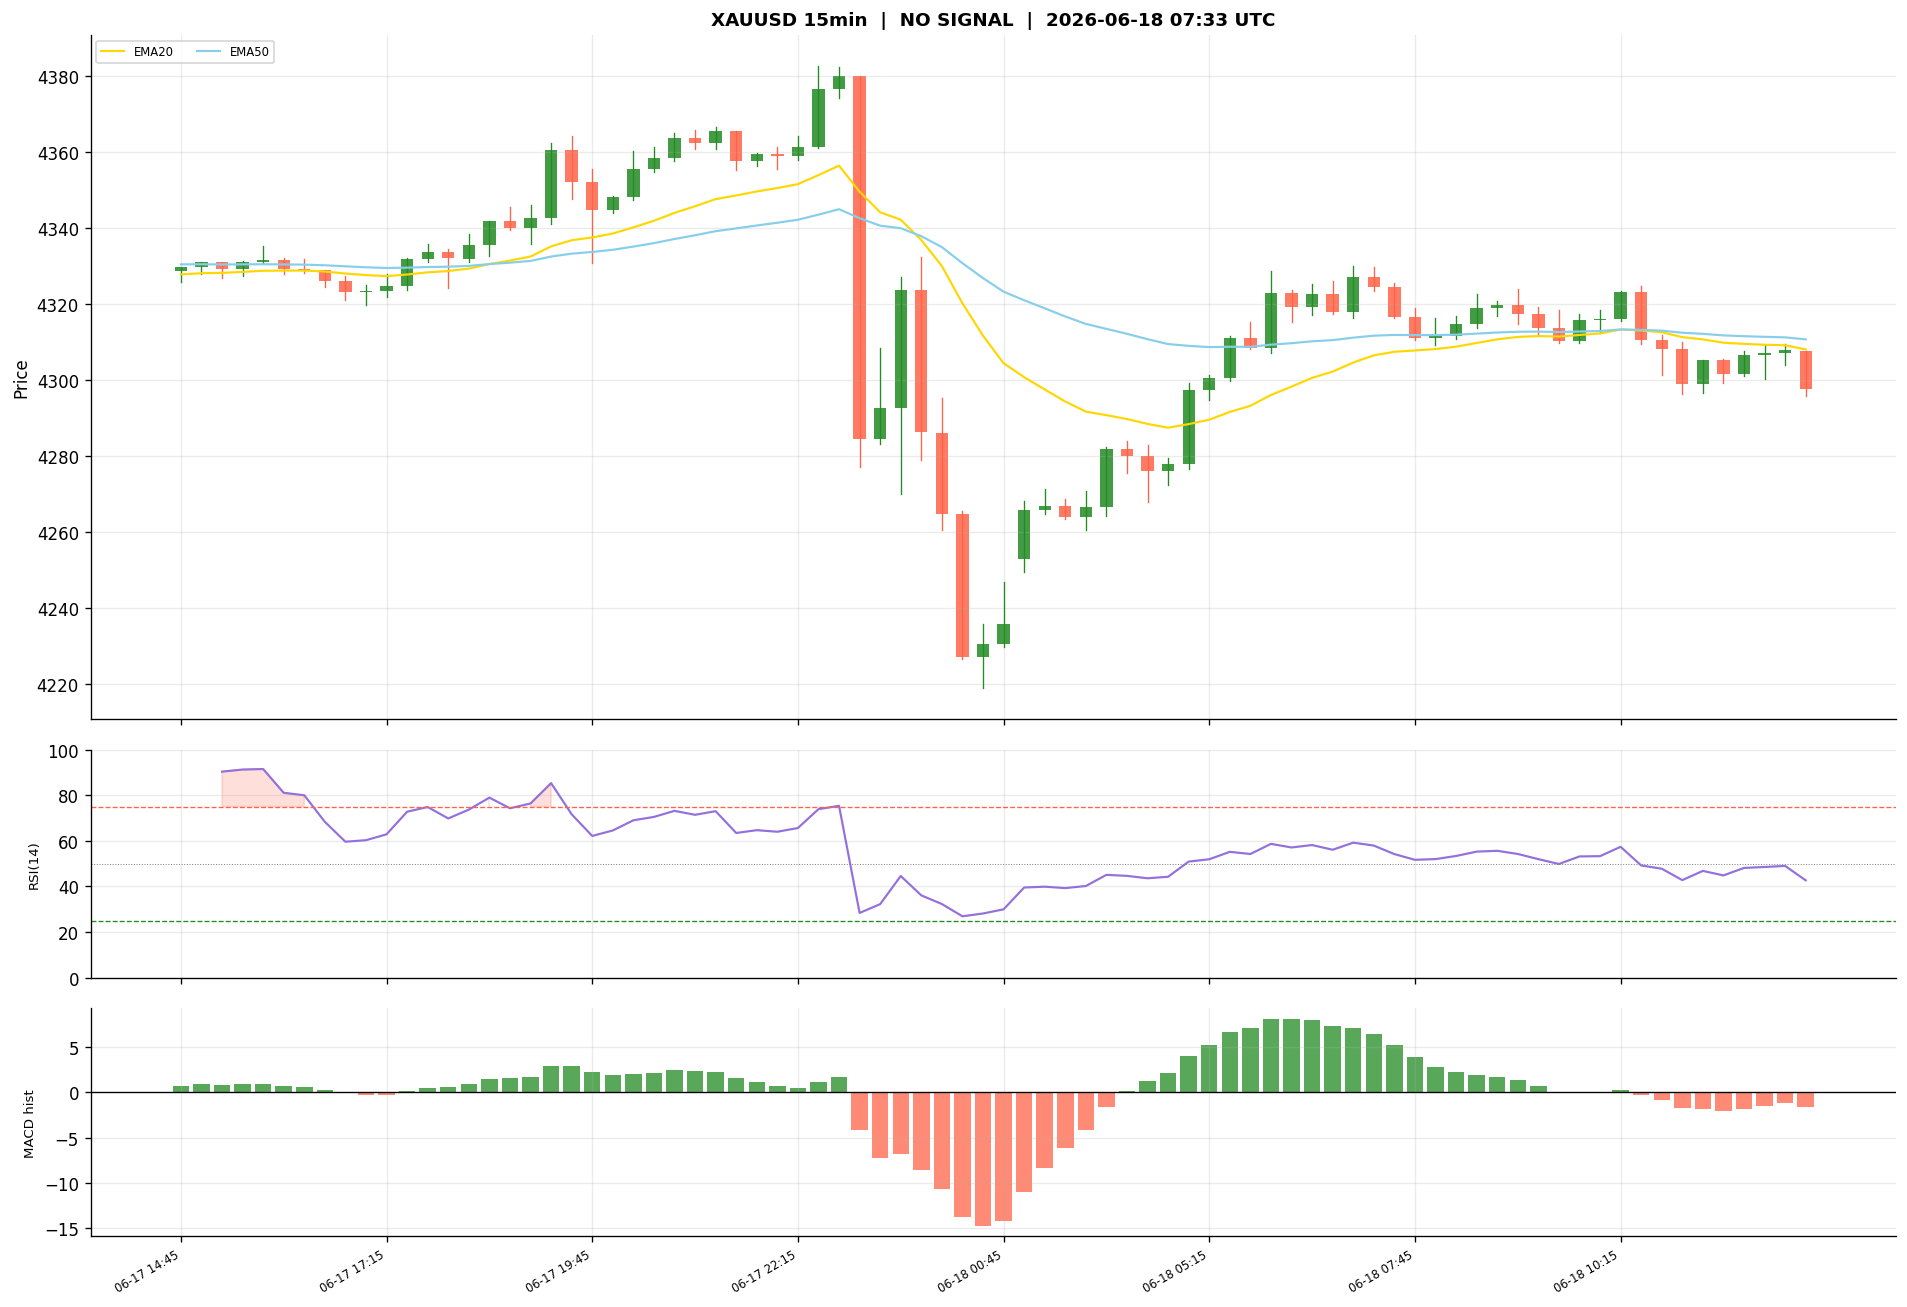

Chart saved: ../results/new_models/plots/signal_chart.png


In [796]:
# ── Chart: candlesticks + EMA + RSI + MACD + signal levels ───────────────

LOOKBACK  = 80
df_plot   = entry_df.tail(LOOKBACK).copy()
feat_plot = compute_features(entry_df).tail(LOOKBACK)
n, xs     = len(df_plot), range(len(df_plot))

fig, (ax1, ax2, ax3) = plt.subplots(
    3, 1, figsize=(16, 11), gridspec_kw={'height_ratios': [3, 1, 1]}, sharex=True
)

# ── Candlesticks ──────────────────────────────────────────────────────────
for i, (_, row) in enumerate(df_plot.iterrows()):
    col = 'forestgreen' if row['close'] >= row['open'] else 'tomato'
    ax1.plot([i, i], [row['low'], row['high']], color=col, lw=0.8)
    ax1.bar(i, abs(row['close'] - row['open']),
            bottom=min(row['open'], row['close']), color=col, alpha=0.85, width=0.6)

# EMAs
for col_name, color, label in [('ema_20', 'gold', 'EMA20'), ('ema_50', 'skyblue', 'EMA50')]:
    if col_name in feat_plot.columns:
        ax1.plot(xs, feat_plot[col_name].values, color=color, lw=1.3, label=label, zorder=3)

# Signal levels
if sig:
    ax1.axhline(sig['entry'], color='royalblue',   ls='--', lw=2.0, label=f'Entry {sig["entry"]:.3f}')
    ax1.axhline(sig['tp'],    color='forestgreen',  ls='-',  lw=2.0, label=f'TP {sig["tp"]:.3f}')
    ax1.axhline(sig['sl'],    color='tomato',        ls='-',  lw=2.0, label=f'SL {sig["sl"]:.3f}')
    ax1.axhspan(min(sig['entry'], sig['tp']), max(sig['entry'], sig['tp']), alpha=0.07, color='forestgreen')
    ax1.axhspan(min(sig['entry'], sig['sl']), max(sig['entry'], sig['sl']), alpha=0.07, color='tomato')
    for lp in sig.get('tp_ladder', []):
        ax1.axhline(lp, color='limegreen', ls=':', lw=1.0, alpha=0.6)

title = (f'{sig["signal"]} | Conf={sig["confidence"]}% | R:R=1:{sig["rr"]:.1f}'
         if sig else 'NO SIGNAL')
ax1.set_title(f'{ASSET} {ENTRY_TF}  |  {title}  |  '
              f'{datetime.now(timezone.utc).strftime("%Y-%m-%d %H:%M UTC")}',
              fontweight='bold', fontsize=11)
ax1.set_ylabel('Price')
ax1.legend(fontsize=7, loc='upper left', ncol=5)

# ── RSI panel ─────────────────────────────────────────────────────────────
rsi_vals = calc_rsi(df_plot['close'], 14).values
ax2.plot(xs, rsi_vals, color='mediumpurple', lw=1.3)
ax2.axhline(RSI_OVERBOUGHT, color='tomato',      ls='--', lw=0.8)
ax2.axhline(RSI_OVERSOLD,   color='forestgreen', ls='--', lw=0.8)
ax2.axhline(50,             color='gray',        ls=':',  lw=0.6)
ax2.fill_between(xs, rsi_vals, RSI_OVERBOUGHT, where=(rsi_vals > RSI_OVERBOUGHT), alpha=0.2, color='tomato')
ax2.fill_between(xs, rsi_vals, RSI_OVERSOLD,   where=(rsi_vals < RSI_OVERSOLD),   alpha=0.2, color='forestgreen')
ax2.set_ylim(0, 100)
ax2.set_ylabel('RSI(14)', fontsize=8)

# ── MACD histogram panel ───────────────────────────────────────────────────
if 'macd_hist' in feat_plot.columns:
    mh = feat_plot['macd_hist'].values
    ax3.bar(xs, mh, color=['forestgreen' if v >= 0 else 'tomato' for v in mh], alpha=0.75)
    ax3.axhline(0, color='black', lw=0.8)
ax3.set_ylabel('MACD hist', fontsize=8)

# X labels
ticks = list(range(0, n, max(1, n // 8)))
ax3.set_xticks(ticks)
ax3.set_xticklabels(
    [df_plot.index[t].strftime('%m-%d %H:%M') for t in ticks],
    rotation=30, ha='right', fontsize=7
)

plt.tight_layout()
out_path = '../results/new_models/plots/signal_chart.png'
os.makedirs(os.path.dirname(out_path), exist_ok=True)
plt.savefig(out_path, bbox_inches='tight')
plt.show()
print(f'Chart saved: {out_path}')

In [797]:
def detect_order_blocks(df, lookback=100,
                        min_move_mult=1.5):
    """
    Detect valid order blocks
    
    Rules:
    - Last candle before impulsive move
    - Move must be significant (min_move_mult × ATR)
    - OB marked as 'fresh' until first touch
    """
    obs    = []
    atr    = calc_atr(df, 14)

    for i in range(3, len(df) - 4):
        candle   = df.iloc[i]
        body     = abs(candle['close'] - candle['open'])
        atr_val  = float(atr.iloc[i])
        next_4   = df.iloc[i+1:i+5]

        # ── Bearish OB ────────────────────────────────────
        # Condition 1: Candle is bullish (green)
        is_green = candle['close'] > candle['open']

        # Condition 2: Next candles are impulsive drop
        drop = candle['high'] - next_4['close'].min()
        is_impulsive_drop = (
            drop >= atr_val * min_move_mult and
            next_4['close'].iloc[-1] < candle['low']
        )

        # Condition 3: At least 2 red candles after
        red_count = sum(
            1 for _, c in next_4.iterrows()
            if c['close'] < c['open']
        )

        if is_green and is_impulsive_drop and red_count >= 2:
            obs.append({
                'type':    'BEARISH',
                'top':     candle['high'],
                'bottom':  candle['open'],  # OB = open to high
                'time':    df.index[i],
                'fresh':   True,
                'strength': drop / atr_val,
                'index':   i
            })

        # ── Bullish OB ────────────────────────────────────
        # Condition 1: Candle is bearish (red)
        is_red = candle['close'] < candle['open']

        # Condition 2: Next candles are impulsive rise
        rise = next_4['close'].max() - candle['low']
        is_impulsive_rise = (
            rise >= atr_val * min_move_mult and
            next_4['close'].iloc[-1] > candle['high']
        )

        # Condition 3: At least 2 green candles after
        green_count = sum(
            1 for _, c in next_4.iterrows()
            if c['close'] > c['open']
        )

        if is_red and is_impulsive_rise and green_count >= 2:
            obs.append({
                'type':    'BULLISH',
                'top':     candle['open'],  # OB = low to open
                'bottom':  candle['low'],
                'time':    df.index[i],
                'fresh':   True,
                'strength': rise / atr_val,
                'index':   i
            })

    return pd.DataFrame(obs) if obs else pd.DataFrame()


def get_fresh_obs(obs_df, df, current_idx):
    """
    Mark OB as mitigated (not fresh)
    if price has already touched it
    Returns only fresh OBs
    """
    if obs_df.empty:
        return obs_df

    fresh_obs = []

    for _, ob in obs_df.iterrows():
        ob_idx = ob['index']

        # Only look at candles after OB formed
        candles_after = df.iloc[ob_idx+4:current_idx]

        if candles_after.empty:
            fresh_obs.append(ob)
            continue

        # Check if price entered OB zone
        touched = any(
            (row['low']  <= ob['top'] and
             row['high'] >= ob['bottom'])
            for _, row in candles_after.iterrows()
        )

        if not touched:
            fresh_obs.append(ob)  # Still fresh ✓

    return pd.DataFrame(fresh_obs)


def price_at_ob(current_price, fresh_obs,
                tolerance=0.002):
    """
    Check if current price is at a fresh OB
    tolerance = 0.2% buffer around OB zone
    """
    if fresh_obs.empty:
        return None

    for _, ob in fresh_obs.iterrows():
        ob_top    = ob['top']    * (1 + tolerance)
        ob_bottom = ob['bottom'] * (1 - tolerance)

        if ob_bottom <= current_price <= ob_top:
            return {
                'found':    True,
                'type':     ob['type'],
                'top':      ob['top'],
                'bottom':   ob['bottom'],
                'strength': ob['strength'],
                'signal':   'SELL' if ob['type'] == 'BEARISH'
                            else 'BUY'
            }

    return None

In [ ]:
def has_broken_structure(df, lookback=20):
    """
    SMC: Check if price has broken recent swing high/low
    Returns (broken, swing_high, swing_low)
    """
    if len(df) < lookback:
        return False, None, None

    recent = df.iloc[-lookback:]
    swing_high = recent['high'].max()
    swing_low = recent['low'].min()
    current_close = df.iloc[-1]['close']

    broken_high = current_close > swing_high
    broken_low = current_close < swing_low

    return (broken_high or broken_low), swing_high, swing_low


def detect_fvg(df, lookback=50):
    """
    Fair Value Gap detection: unfilled gaps between candles
    Returns list of {type, bottom, top, index}
    """
    fvgs = []
    df_len = len(df)

    for i in range(1, min(lookback, df_len - 1)):
        idx = df_len - lookback + i
        if idx < 1:
            continue

        # Bullish FVG: red candle → green candle (gap up)
        if (df.iloc[idx-1]['close'] < df.iloc[idx-1]['open'] and
            df.iloc[idx]['close'] > df.iloc[idx]['open']):

            gap_bottom = df.iloc[idx-1]['close']
            gap_top = df.iloc[idx]['open']

            if gap_top > gap_bottom:
                filled = False
                for j in range(idx + 1, min(idx + lookback, df_len)):
                    if df.iloc[j]['low'] <= gap_bottom:
                        filled = True
                        break
                if not filled:
                    fvgs.append({'type': 'BULLISH', 'bottom': gap_bottom, 'top': gap_top, 'index': idx})

        # Bearish FVG: green candle → red candle (gap down)
        if (df.iloc[idx-1]['close'] > df.iloc[idx-1]['open'] and
            df.iloc[idx]['close'] < df.iloc[idx]['open']):

            gap_top = df.iloc[idx-1]['close']
            gap_bottom = df.iloc[idx]['open']

            if gap_bottom < gap_top:
                filled = False
                for j in range(idx + 1, min(idx + lookback, df_len)):
                    if df.iloc[j]['high'] >= gap_top:
                        filled = True
                        break
                if not filled:
                    fvgs.append({'type': 'BEARISH', 'bottom': gap_bottom, 'top': gap_top, 'index': idx})

    return fvgs


def validate_entry_with_smc(df, current_price, signal_direction, fresh_obs):
    """
    SMC Entry Validation (3 checks):
    1. Price broken structure? ✓
    2. OB retest (near fresh OB)? ✓  
    3. Not inside FVG? ✓
    Returns (valid, reason)
    """
    # Check 1: Structure break
    broken, swing_h, swing_l = has_broken_structure(df, lookback=20)
    if not broken:
        return False, "No structure break"

    if signal_direction == 'BUY' and current_price <= swing_l:
        return False, "BUY but price ≤ swing low"
    if signal_direction == 'SELL' and current_price >= swing_h:
        return False, "SELL but price ≥ swing high"

    # Check 2: OB retest
    ob_touch = price_at_ob(current_price, fresh_obs, tolerance=0.005)
    if not ob_touch or not ob_touch.get('found'):
        return False, "Price not at OB zone"

    # Check 3: FVG avoidance
    fvgs = detect_fvg(df, lookback=50)
    for fvg in fvgs:
        if fvg['bottom'] <= current_price <= fvg['top']:
            return False, f"Price inside {fvg['type']} FVG"

    return True, "✓ All SMC checks passed"

In [ ]:
import threading
import time
import requests
from datetime import datetime, timezone

LIVE             = True
SCAN_INTERVAL_S  = 120
SCAN_WITH_TRADE  = 2700 * 2

# ── Override filters ──────────────────────────────────────────
ADX_TREND_THRESHOLD  = 20
CONFIDENCE_THRESHOLD = 60
RSI_OVERBOUGHT       = 75
RSI_OVERSOLD         = 20

try:
    live_stop.set()
    time.sleep(3)
except:
    pass

live_stop = threading.Event()

# ── Discord Webhooks (ONLY YOURS) ─────────────────────────────
DISCORD_WEBHOOK_URLS = [
    "https://discord.com/api/webhooks/1512351711933759641/Fx6qmVuxBlJF2VfOc6IWbrxFI9y3-XR_jDUIayTTFC887IDMDWI0shJ-jJDGCk_f4TRy",
]

# ── User packages ─────────────────────────────────────────────
USERS = {
    '8300273044': 200,
}

# ── Per-user signal counter ───────────────────────────────────
_user_signals = {}

def send_to_discord(embed_payload):
    """Send to configured Discord webhooks with fail-safe error handling"""
    for url in DISCORD_WEBHOOK_URLS:
        try:
            response = requests.post(url, json=embed_payload, timeout=10)
            print(f'  → Discord sent ✓ ({response.status_code})')
        except requests.exceptions.RequestException as e:
            print(f'  → Discord Network/DNS Error (Internet issues): {e}')
        except Exception as e:
            print(f'  → Discord Unexpected error: {e}')


def check_and_send_discord_embed(
    stock_name, direction, entry_zone, ladder,
    conf, tp_prob, f_adx, f_rsi,
    aligned_tfs, total_tfs, pred_return,
    news_warning, sentiment_warning,
    ob_line, now_str, smc_status, smc_reason
):
    today       = datetime.now(timezone.utc).date()
    embed_color = 3066993 if direction == 'BUY' else 15158332
    discord_ts  = f"<t:{int(time.time())}:f>"

    for chat_id, limit in USERS.items():
        if chat_id not in _user_signals:
            _user_signals[chat_id] = {'date': today, 'count': 0}
        user = _user_signals[chat_id]

        if user['date'] != today:
            user['date']  = today
            user['count'] = 0

        if user['count'] < limit:
            signal_payload = {
                "username": "ARH Signal Engine",
                "content": "@everyone 🔥 New Limit Order Signal!",
                "embeds": [{
                    "title": f"{'🟢' if direction == 'BUY' else '🔴'} {direction} LIMIT {stock_name} {smc_status}",
                    "description": (
                        f"📅 **Time:** {discord_ts}\n"
                        f"📊 **Usage:** `{user['count'] + 1}/{limit}`\n"
                        f"🔍 **SMC Check:** {smc_reason}"
                    ),
                    "color": embed_color,
                    "fields": [
                        {
                            "name": "🔑 Optimal Entry Zone (5m Buffer)",
                            "value": f"**{entry_zone['lower']:.3f} — {entry_zone['upper']:.3f}**\n*(Base Entry: {entry_zone['base']:.3f})*",
                            "inline": False
                        },
                        {
                            "name": "🛑 SL (System)",
                            "value": f"`{ladder['sl1']:.3f}` (-{ladder['pips_sl1']} pips)",
                            "inline": False
                        },
                        {
                            "name": "🎯 TP1 (Quick)",
                            "value": f"`{ladder['tp1']:.3f}` (+{ladder['pips_tp1']} pips)",
                            "inline": True
                        },
                        {
                            "name": "🎯 TP2 (Mid)",
                            "value": f"`{ladder['tp2']:.3f}` (+{ladder['pips_tp2']} pips)",
                            "inline": True
                        },
                        {
                            "name": "🎯 TP3 (System)",
                            "value": f"`{ladder['tp3']:.3f}` (+{ladder['pips_tp3']} pips)",
                            "inline": True
                        },
                        {
                            "name": "🔮 Pred Return",
                            "value": f"**{pred_return:+.4f}**",
                            "inline": True
                        },
                        {
                            "name": "📦 Order Block",
                            "value": ob_line,
                            "inline": False
                        },
                    ],
                    "footer": {
                        "text": "🔬 Beta Testing — Ahmed R. Hussain"
                    }
                }]
            }
            send_to_discord(signal_payload)
            user['count'] += 1
            print(f'  → Signal sent ({user["count"]}/{limit})')

        else:
            limit_payload = {
                "username": "ARH Signal Engine",
                "embeds": [{
                    "title": "🔒 Daily Limit Reached",
                    "description": f"All **{limit}/{limit}** signals used for today.",
                    "color": 16711680,
                    "fields": [
                        {
                            "name": "Upgrade Package",
                            "value": "• Standard — 10 signals/day\n• Premium  — Unlimited",
                            "inline": False
                        },
                        {
                            "name": "📩 Contact",
                            "value": "@ahmedrh_signals",
                            "inline": True
                        }
                    ],
                    "footer": {
                        "text": "🔬 Beta Testing — Ahmed R. Hussain"
                    }
                }]
            }
            send_to_discord(limit_payload)
            print(f'  → Limit reached for {chat_id}')


# ── CORRECTED SMART PIP LADDER ────────────────────────────────
def calculate_ladder(entry, direction, atr, sl_mult, rr_ratio):
    if atr is None or atr <= 0:
        sl_distance = entry * 0.002
    else:
        sl_distance = atr * sl_mult

    if entry > 1000:  # ── Gold (XAUUSD) Specific ──
        pip_multiplier = 10.0
        pips_sl1 = int(round(sl_distance * pip_multiplier))
        
        pips_tp1 = 100
        tp1_distance = 10.0  
        
        tp3_distance = sl_distance * rr_ratio
        pips_tp3 = int(round(tp3_distance * pip_multiplier))
        
        tp2_distance = (tp1_distance + tp3_distance) / 2
        pips_tp2 = int(round(tp2_distance * pip_multiplier))

    elif entry < 2.5:  # ── Standard Forex (EURUSD, etc.) ──
        pip_multiplier = 10000.0
        pips_sl1 = int(round(sl_distance * pip_multiplier))
        pips_tp1 = 15
        tp1_distance = pips_tp1 / pip_multiplier
        tp3_distance = sl_distance * rr_ratio
        pips_tp3 = int(round(tp3_distance * pip_multiplier))
        tp2_distance = (tp1_distance + tp3_distance) / 2
        pips_tp2 = int(round(tp2_distance * pip_multiplier))
        
    else:  # ── Indices / JPY Pairs ──
        pip_multiplier = 10.0 if entry > 100 else 100.0
        pips_sl1 = int(round(sl_distance * pip_multiplier))
        pips_tp1 = 90
        tp1_distance = pips_tp1 / pip_multiplier
        tp3_distance = sl_distance * rr_ratio
        pips_tp3 = int(round(tp3_distance * pip_multiplier))
        tp2_distance = (tp1_distance + tp3_distance) / 2
        pips_tp2 = int(round(tp2_distance * pip_multiplier))

    if direction == 'BUY':
        sl1 = entry - sl_distance
        tp1 = entry + tp1_distance
        tp2 = entry + tp2_distance
        tp3 = entry + tp3_distance
    else:
        sl1 = entry + sl_distance
        tp1 = entry - tp1_distance
        tp2 = entry - tp2_distance
        tp3 = entry - tp3_distance

    return {
        'sl1':      round(sl1, 2),
        'tp1':      round(tp1, 2),
        'tp2':      round(tp2, 2),
        'tp3':      round(tp3, 2),
        'pips_sl1': pips_sl1 if pips_sl1 > 0 else 15,
        'pips_tp1': pips_tp1,
        'pips_tp2': pips_tp2,
        'pips_tp3': pips_tp3,
    }


# ── OPTIMAL 5-MIN TF ENTRY ZONE CALCULATION ─────────────────────
def calculate_optimal_entry_zone(base_price, direction, fresh_data, asset):
    try:
        f_5m = fresh_data.get('5min', fresh_data[list(fresh_data.keys())[0]])
        atr_5m = float(calc_atr(f_5m, 14).iloc[-1])
    except:
        atr_5m = base_price * 0.0005  # Fallback buffer

    buffer_offset = atr_5m * 0.3

    if direction == 'BUY':
        lower_bound = base_price - buffer_offset
        upper_bound = base_price + (buffer_offset * 0.5)
    else:
        lower_bound = base_price - (buffer_offset * 0.5)
        upper_bound = base_price + buffer_offset

    return {
        'base':  base_price,
        'lower': round(lower_bound, 2) if asset == 'XAUUSD' else round(lower_bound, 4),
        'upper': round(upper_bound, 2) if asset == 'XAUUSD' else round(upper_bound, 4)
    }


# ── News functions ────────────────────────────────────────────
def get_news_events():
    try:
        url = "https://nfs.faireconomy.media/ff_calendar_thisweek.json"
        r      = requests.get(url, timeout=10)
        events = r.json()
        now    = datetime.now(timezone.utc)
        upcoming = []
        for event in events:
            if event.get('impact') != 'High':
                continue
            try:
                et = datetime.fromisoformat(event['date'].replace('Z', '+00:00'))
                diff = (et - now).total_seconds() / 60
                if -30 <= diff <= 60:
                    upcoming.append({
                        'title':   event.get('title', ''),
                        'country': event.get('country', ''),
                        'minutes': diff
                    })
            except:
                continue
        return upcoming
    except:
        return []


def is_news_zone():
    events   = get_news_events()
    relevant = ['USD', 'XAU', 'US']
    for event in events:
        if event['country'] in relevant:
            return True, event
    return False, None


def get_fear_greed():
    try:
        url = "https://production.dataviz.cnn.io/index/fearandgreed/graphdata"
        headers = {'User-Agent': 'Mozilla/5.0'}
        r       = requests.get(url, headers=headers, timeout=10)
        data   = r.json()
        score  = float(data['fear_and_greed']['score'])
        rating = data['fear_and_greed']['rating']
        return score, rating
    except:
        return 50, 'neutral'


def get_sentiment_bias(direction):
    score, rating = get_fear_greed()
    if direction == 'BUY':
        if score < 40:
            return f'😨 Fear ({score:.0f}) confirms BUY'
        elif score > 60:
            return f'😎 Greed ({score:.0f}) — caution BUY'
        else:
            return f'😐 Neutral ({score:.0f})'
    else:
        if score > 60:
            return f'😎 Greed ({score:.0f}) confirms SELL'
        elif score < 40:
            return f'😨 Fear ({score:.0f}) — caution SELL'
        else:
            return f'😐 Neutral ({score:.0f})'


# ── Scanner ───────────────────────────────────────────────────
_scanner_running = False

def _live_worker():
    global _scanner_running

    if _scanner_running:
        print("Already running — skipping")
        return

    _scanner_running  = True
    _count            = 0
    _last             = None
    _last_signal_time = None
    _last_signal_dir  = None
    _trade_open       = False
    _trade_open_time  = None
    SIGNAL_COOLDOWN   = 2700
    TRADE_TIMEOUT     = 14400

    print("Scanner started — single instance")
    print(f"No trade:    every {SCAN_INTERVAL_S}s")
    print(f"Trade open:  every {SCAN_WITH_TRADE}s")
    print(f"Discord Engine Integrated Successfully. (Single Target Mode)")
    print(f"SMC Filter:  {'ON' if USE_SMC_FILTER else 'OFF'}")

    while not live_stop.is_set():
        _count += 1
        now = datetime.now(timezone.utc).strftime('%H:%M:%S UTC')

        if _trade_open and _trade_open_time:
            age = (datetime.now(timezone.utc) - _trade_open_time).seconds
            if age > TRADE_TIMEOUT:
                _trade_open      = False
                _trade_open_time = None
                print(f'[{now}] Trade auto-reset')

        current_interval = SCAN_WITH_TRADE if _trade_open else SCAN_INTERVAL_S

        try:
            execution_timeframes = list(set(TIMEFRAMES + ['5min']))
            fresh   = fetch_multi_timeframe(ASSET, execution_timeframes, bars=500)
            f_entry = fresh[ENTRY_TF]
            f_price = float(f_entry['close'].iloc[-1])
            f_atr   = float(calc_atr(f_entry, 14).iloc[-1])
            f_fc    = run_ensemble_forecast(f_entry, ENTRY_TF, TRAIN_BARS, FORECAST_H, use_chronos=USE_CHRONOS)
            bar_id  = str(f_entry.index[-1])
            dir_lbl = 'BUY' if f_fc['direction'] > 0 else 'SELL' if f_fc['direction'] < 0 else 'FLAT'

            if dir_lbl != 'FLAT' and bar_id != _last:
                _last = bar_id

                f_feat  = compute_features(f_entry)
                f_adx   = float(f_feat['adx_14'].iloc[-1]) if 'adx_14' in f_feat.columns else 0
                f_rsi   = float(f_feat['rsi_14'].iloc[-1]) if 'rsi_14' in f_feat.columns else 50
                f_macd  = float(f_feat['macd_hist'].iloc[-1]) if 'macd_hist' in f_feat.columns else 0
                f_ema20 = float(f_feat['ema_20'].iloc[-1]) if 'ema_20' in f_feat.columns else f_price

                if f_adx < ADX_TREND_THRESHOLD:
                    print(f'[{now}][{_count:4d}] SKIP — ADX={f_adx:.1f}')
                    continue

                if dir_lbl == 'BUY' and f_rsi > RSI_OVERBOUGHT:
                    print(f'[{now}][{_count:4d}] SKIP BUY — RSI={f_rsi:.0f}')
                    continue
                if dir_lbl == 'SELL' and f_rsi < RSI_OVERSOLD:
                    print(f'[{now}][{_count:4d}] SKIP SELL — RSI={f_rsi:.0f}')
                    continue

                if _last_signal_time and dir_lbl == _last_signal_dir:
                    elapsed = (datetime.now(timezone.utc) - _last_signal_time).seconds
                    if elapsed < SIGNAL_COOLDOWN:
                        print(f'[{now}][{_count:4d}] SKIP — cooldown {elapsed}s')
                        continue

                f_snaps  = build_multi_tf_snapshot(fresh)
                f_scores = {tf: _score_timeframe(snap) for tf, snap in f_snaps.items() if tf in TIMEFRAMES}
                aligned = [tf for tf, sc in f_scores.items() if sc['direction'] == (1 if dir_lbl == 'BUY' else -1)]
                opposite = [tf for tf, sc in f_scores.items() if sc['direction'] == (-1 if dir_lbl == 'BUY' else 1)]
                total_tfs = len(f_scores)
                align_pct = (len(aligned) / total_tfs * 100 if total_tfs > 0 else 0)

                if len(aligned) < 2:
                    print(f'[{now}][{_count:4d}] SKIP — {len(aligned)}/{total_tfs} TFs')
                    continue

                conf  = 0
                conf += min(35, int(align_pct * 0.5))
                conf += (20 if f_adx >= ADX_TREND_THRESHOLD else 5)
                conf += (15 if abs(f_fc['pred_return']) > 0.0003 else 8)
                conf += (15 if (f_macd > 0) == (dir_lbl == 'BUY') else 0)
                conf += (10 if (f_price > f_ema20) == (dir_lbl == 'BUY') else 0)
                conf += 5 if len(opposite) == 0 else 0
                conf  = min(conf, 95)

                if conf < CONFIDENCE_THRESHOLD:
                    print(f'[{now}][{_count:4d}] SKIP — conf={conf}%')
                    continue

                # ── SMC CHECK (REPORT ONLY, DON'T SKIP) ───────────────────────────────
                smc_status = ''
                smc_reason = 'SMC OFF'
                if USE_SMC_FILTER:
                    try:
                        obs_df    = detect_order_blocks(f_entry)
                        fresh_obs = get_fresh_obs(obs_df, f_entry, current_idx=len(f_entry)-1)
                        smc_valid, smc_reason = validate_entry_with_smc(f_entry, f_price, dir_lbl, fresh_obs)
                        
                        if smc_valid:
                            smc_status = ' | SMC=✓'
                        else:
                            smc_status = f' | SMC=✗ ({smc_reason})'
                    except Exception as e:
                        smc_reason = f'SMC error: {e}'
                        smc_status = ' | SMC=ERROR'

                tp_prob = (70 if f_adx >= 40 else 58 if f_adx >= 30 else 48)
                if abs(f_fc['pred_return']) >= 0.0003:
                    tp_prob += 10
                elif abs(f_fc['pred_return']) >= 0.0002:
                    tp_prob += 5
                tp_prob = min(tp_prob, 85)

                e = float(f_entry['close'].iloc[-1])
                
                entry_zone = calculate_optimal_entry_zone(e, dir_lbl, fresh, ASSET)
                ladder = calculate_ladder(e, dir_lbl, f_atr, sl_mult=ATR_SL_MULT, rr_ratio=RR_RATIO)
                
                if USE_SMC_FILTER:
                    try:
                        ob_result = price_at_ob(f_price, fresh_obs)
                        ob_line = f"{ob_result['type']} | Zone: {ob_result['bottom']:.3f} — {ob_result['top']:.3f} | Strength: {ob_result['strength']:.1f}x ATR" if ob_result else "None detected"
                    except:
                        ob_line = "SMC error"
                else:
                    ob_line = "SMC OFF"

                in_nz, nz_event = is_news_zone()
                news_warning = f'⚠️ NEWS: {nz_event["title"]} in {nz_event["minutes"]:.0f} min' if in_nz else '📰 News: Clear'
                sentiment_warning = get_sentiment_bias(dir_lbl)

                _last_signal_time = datetime.now(timezone.utc)
                _last_signal_dir  = dir_lbl
                _trade_open       = True
                _trade_open_time  = datetime.now(timezone.utc)

                print(
                    f'\n📅 {datetime.now(timezone.utc).strftime("%A, %d %b %Y")} | 🕐 {now}\n'
                    f'[{_count:4d}] ⭐ {dir_lbl} LIMIT {ASSET} ALERT{smc_status}\n'
                    f'───────────────────────────────────────────\n'
                    f'🔑 ENTRY ZONE : {entry_zone["lower"]:.3f} — {entry_zone["upper"]:.3f}\n'
                    f'🛑 SL (System): {ladder["sl1"]:.3f} (-{ladder["pips_sl1"]} pips)\n'
                    f'🎯 TP1 (Quick): {ladder["tp1"]:.3f} (+{ladder["pips_tp1"]} pips)\n'
                    f'🎯 TP2 (Mid)  : {ladder["tp2"]:.3f} (+{ladder["pips_tp2"]} pips)\n'
                    f'🎯 TP3 (System): {ladder["tp3"]:.3f} (+{ladder["pips_tp3"]} pips)\n'
                    f'───────────────────────────────────────────\n'
                    f'📈 Conf={conf}% | ADX={f_adx:.1f} | TFs={len(aligned)}/{total_tfs}\n'
                )

                check_and_send_discord_embed(
                    stock_name=ASSET, direction=dir_lbl, entry_zone=entry_zone, ladder=ladder,
                    conf=conf, tp_prob=tp_prob, f_adx=f_adx, f_rsi=f_rsi,
                    aligned_tfs=len(aligned), total_tfs=total_tfs, pred_return=f_fc['pred_return'],
                    news_warning=news_warning, sentiment_warning=sentiment_warning,
                    ob_line=ob_line, now_str=now, smc_status=smc_status, smc_reason=smc_reason
                )

                try:
                    from src.signal_logger import SignalLogger
                    logger = SignalLogger()
                    logger.log_signal(
                        asset=ASSET, timeframe=ENTRY_TF, signal=dir_lbl, entry=e,
                        stop_loss=ladder['sl1'], take_profit=ladder['tp3'],
                        pred=f_fc['pred_return'], adx=f_adx, confidence=conf,
                        tp_prob=tp_prob, timestamp=now, ladder=ladder
                    )
                except Exception as log_err:
                    print(f'  → SignalLogger pipeline bypass (Handled): {log_err}')

            else:
                if _count % 3 == 0:
                    status = 'TRADE OPEN (45min)' if _trade_open else 'No trade (5min)'
                    print(f'[{now}][{_count:4d}] {dir_lbl:4s} | {f_price:.3f} | {status}')

        except Exception as exc:
            print(f'[{now}] Error: {exc}')

        live_stop.wait(current_interval)

    _scanner_running = False
    print('Scanner stopped.')


# ── Start ──────────────────────────────────────────────────────
if LIVE:
    live_stop.clear()
    t = threading.Thread(target=_live_worker, name='scanner', daemon=True)
    t.start()
    print(f'Live scanner ON: {ASSET} {ENTRY_TF}')
    print(f'No trade:    every 5 min')
    print(f'Trade open:  every 45 min')
    print('Set LIVE=False and re-run to stop.')
else:
    live_stop.set()
    print('Scanner OFF.')